Sentiment Analysis

Mohamad Mohannad Al Kawadri




## Assignment Submission
To complete this assignment answer the questions in this notebook and write the code required to implement the relevant models.
However, we reccomend that you start early. This assignment has subsections, each of which build upon the last. This assignment is completed by doing the following.

- Submit notebook as an .ipynb file to canvas.
- Submit notebook as an .pdf file to canvas.

Your submission must correctly implement the full pipeline to analyse the sentiment using a RNN and BERT models.


#### NOTE: It is recommended to use Google Colab with GPU enabled for CA5 tasks. Keras and TensorFlow (version ≥2) will automatically use the GPU if one is available

- Read tasks thoroughly before answering.
- Make sure to answer all tasks.
- Ensure all code cells are run.
- Ensure all figures are visible in the PDF.
- Provide a brief explanation of how your code works

# How to Use Google Colab for CA5

To work on the CA5 assignment in Google Colab, follow these steps:

---

### 1. Connect Google Colab to Google Drive
Your CA5 files should be stored in Google Drive so Colab can access them.  
Run the following code to mount your Drive:



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
project_path = "/content/drive/MyDrive/Colab_Notebooks" #change this to your folder.
os.chdir(project_path)
print("Current working directory:", os.getcwd())

Current working directory: /content/drive/MyDrive/Colab_Notebooks


### Change Runtime to GPU

To use GPU in Google Colab:

1. Go to the top menu and click **Runtime** → **Change runtime type**.  
2. In the pop-up window, set **Hardware accelerator** to **GPU**.  
3. Click **Save**.  

Now your notebook will run on a GPU backend.

###**Note**: I recommend using the regular runtime first, as your GPU usage is limited. Write and test your code in the regular runtime to ensure everything works correctly before switching to the GPU for model training.

##Introduction
In this assignment, you will analyze whether a movie review is positive or negative. In Task 1, you will use a Recurrent Neural Network (RNN) to perform the analysis. In Task 2, you will be introduced to the encoder block of the Transformer architecture, commonly known as BERT. Finally, you will compare the results from both approaches and draw a conclusion.

**Note**: BERT stands for "Bidirectional Encoder Representations from Transformers"

###About the Dataset
The IMDb dataset is a collection of 50,000 reviews from the Internet Movie Database (IMDb). The reviews are labeled as either positive or negative.

The IMDb dataset is a binary sentiment analysis dataset for natural language processing or text analytics.

IMDb is a rich source of film data that includes cast and crew lists, movie release dates, box office information, plot summaries, trailers, actor and director biographies, and other trivia. Information on IMDb comes from a variety of sources, such as filmmakers, film studios, on-screen credits, and other official sources.

## Task 0: Load and Inspect the Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv("IMDB Dataset.csv")

In [5]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


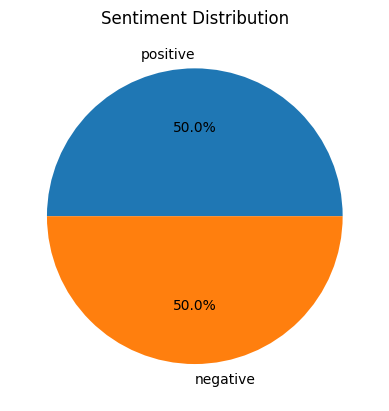

In [6]:
sentiment_counts = data["sentiment"].value_counts()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.show()


### Preprocess

In [7]:
from sklearn.preprocessing import LabelEncoder
import re
from sklearn.model_selection import train_test_split

In [8]:
labels = data["sentiment"]
enc = LabelEncoder()
labels_encoded = enc.fit_transform(labels)
data["labels_encoded"] = labels_encoded

In [9]:
data.head()

,review,sentiment,labels_encoded
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [10]:
def clean_text(text):
    text = re.sub(r"<br\s*/?>", " ", text)  # remove <br> or <br />
    text = re.sub(r"&nbsp;", " ", text)
    text = re.sub(r"http\S+", " ", text)    # remove URLs
    text = re.sub(r"@\w+", " ", text)       # remove @mentions
    text = re.sub(r"[^A-Za-z0-9\s.,!?']", " ", text)# strip symbols
    text = re.sub(r"\s+", " ", text).strip()
    return text

data["review"] = data["review"].apply(clean_text)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(data["review"], data["labels_encoded"], test_size=0.25)

## Task 1: RNN

### 1.1 Vectorize inputs

In [14]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras import layers, Sequential


max_tokens = 30000      # vocab size cap
max_len    = 128        # sequence length

vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",                 # output integer token IDs
    output_sequence_length=max_len,    # pad/truncate sequences to 128
    standardize="lower_and_strip_punctuation"  # clean text
)

vectorizer.adapt(tf.data.Dataset.from_tensor_slices(X_train).batch(1024))

X = vectorizer(X_train)

### Task 1.1 Create a simple RNN and an LSTM model

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# Simple RNN Model
rnn_model = Sequential([
    layers.Embedding(input_dim=max_tokens, output_dim=64, input_length=max_len),
    layers.SimpleRNN(64),
    layers.Dense(1, activation="sigmoid")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [16]:
# LSTM Model
lstm_model = Sequential([
    layers.Embedding(input_dim=max_tokens, output_dim=64, input_length=max_len),
    layers.LSTM(64),
    layers.Dense(1, activation="sigmoid")
])


### Compile and print out summary

In [17]:
rnn_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

lstm_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


In [18]:
print("----- Simple RNN Model Summary -----")
rnn_model.summary()

print("\n----- LSTM Model Summary -----")
lstm_model.summary()


----- Simple RNN Model Summary -----


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Task 1.2: Train your model

In [20]:
X_train_vec = vectorizer(X_train)
X_test_vec = vectorizer(X_test)

# Train the Simple RNN Model
history_rnn = rnn_model.fit(
    X_train_vec,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32
)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8694 - loss: 0.3131 - val_accuracy: 0.6361 - val_loss: 0.8359
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8236 - loss: 0.3546 - val_accuracy: 0.6036 - val_loss: 0.9019
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8528 - loss: 0.2802 - val_accuracy: 0.5571 - val_loss: 1.1590
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8892 - loss: 0.2255 - val_accuracy: 0.5385 - val_loss: 1.2555
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8894 - loss: 0.2144 - val_accuracy: 0.6125 - val_loss: 1.1512


In [21]:
# Train the LSTM Model
history_lstm = lstm_model.fit(
    X_train_vec,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32
)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7821 - loss: 0.4770 - val_accuracy: 0.7289 - val_loss: 0.5711
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7072 - loss: 0.5550 - val_accuracy: 0.7785 - val_loss: 0.4799
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8855 - loss: 0.2965 - val_accuracy: 0.8415 - val_loss: 0.4004
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9271 - loss: 0.2105 - val_accuracy: 0.8404 - val_loss: 0.4654
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9424 - loss: 0.1669 - val_accuracy: 0.8268 - val_loss: 0.4950


### Task 1.3 Evaluate your models

In [22]:
# Evaluate the Simple RNN Model
rnn_loss, rnn_acc = rnn_model.evaluate(X_test_vec, y_test, verbose=1)
print(f"Simple RNN - Test Accuracy: {rnn_acc:.4f}, Test Loss: {rnn_loss:.4f}")

391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6073 - loss: 1.1513
Simple RNN - Test Accuracy: 0.6112, Test Loss: 1.1406


In [23]:
# Evaluate the LSTM Model
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_vec, y_test, verbose=1)
print(f"LSTM - Test Accuracy: {lstm_acc:.4f}, Test Loss: {lstm_loss:.4f}")

391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8284 - loss: 0.5072
LSTM - Test Accuracy: 0.8259, Test Loss: 0.5025


### Task 2: BERT

### Task 2.0: Install the trasformers package from HuggingFace

Hugging Face is an American company and an open-source community that provides tools, pre-trained machine learning models, and datasets, primarily focused on natural language processing (NLP) and other AI fields like computer vision and audio

**Note:** You may need to restart the runtime after installing the packages. Then, mount your Google Drive and rerun Task 0.

In [24]:
!pip install -U "tensorflow>=2.17,<2.21" "keras>=3.3.0" "tf-keras>=2.17" "transformers>=4.44.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 858.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.3 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
  Attempting uninstall: tf-keras
    Found existing installation: tf_keras 2.19.0
    Uninstalling tf_keras-2.19.0:
      Successfully uninstalled tf_keras-2.19.0
ERROR: pip's dependency reso

In [12]:
import tf_keras as keras
import tensorflow as tf
from transformers import TFDistilBertForSequenceClassification, AutoTokenizer

### Task 2.1: Load the destilbert model

In this part of the assignment, we will use a smaller and faster version of BERT called DistilBERT. It is significantly more lightweight and trains much faster than the original BERT model. Here is the illustration of its architecture:

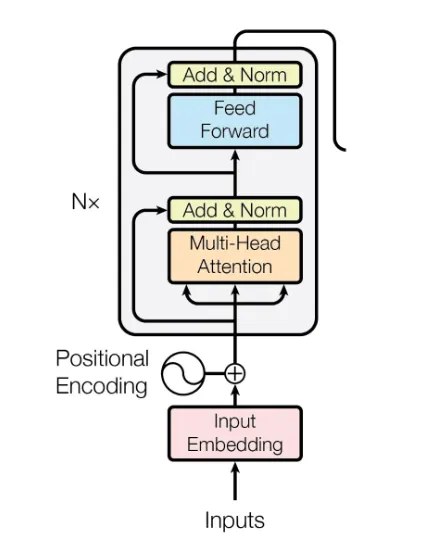

In [13]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model =  TFDistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2, from_pt=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias', 'vocab_projector.weight', 'vocab_transform.bias', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSeq

### Task 2.2: Split the training data to Validation and training

In [14]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2)

### Task 2.3: Tokenize

You have to tokenize your inputs again, use the AutoTokenizer that we imported earlier.

In [15]:
max_len   = 128
batch_sz  = 64
epochs    = 3

enc_train = tokenizer(
    X_train.astype(str).tolist(), truncation=True, padding="max_length",
    max_length=max_len, return_tensors="np"
)
enc_val = tokenizer(
    X_val.astype(str).tolist(), truncation=True, padding="max_length",
    max_length=max_len, return_tensors="np"
)


### Create datasets

This step wraps your input features (enc_train, e.g., input_ids and attention_mask) and labels (y_train) into a TensorFlow-native streaming dataset.

The TensorFlow Dataset API provides an efficient way to feed data to your model:

* Streams data efficiently from RAM or disk.

* Performs batching, shuffling, and preprocessing in parallel on the CPU.

* Keeps the GPU busy by prefetching the next batch while training.

* Integrates seamlessly with Hugging Face's encoded token dictionaries.




In [16]:
ds_train = tf.data.Dataset.from_tensor_slices((dict(enc_train), y_train))
ds_train = ds_train.map(lambda x, y: (x, tf.cast(tf.squeeze(y), tf.int32))) \
                   .shuffle(10000).batch(batch_sz).prefetch(tf.data.AUTOTUNE)

ds_val = tf.data.Dataset.from_tensor_slices((dict(enc_val), y_val))
ds_val = ds_val.map(lambda x, y: (x, tf.cast(tf.squeeze(y), tf.int32))) \
               .batch(batch_sz).prefetch(tf.data.AUTOTUNE)


### Task 2.4: Create and Compile model

In [17]:
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)

model.summary()

Model: "tf_distil_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
 dropout_19 (Dropout)        multiple                  0         
                                                                 
Total params: 66955010 (255.41 MB)
Trainable params: 66955010 (255.41 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Task 2.5: Train your model

In [18]:
history_bert = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=epochs
)

Epoch 1/3
469/469 [==============================] - 423s 839ms/step - loss: 0.3418 - accuracy: 0.8471 - val_loss: 0.2775 - val_accuracy: 0.8829
Epoch 2/3
469/469 [==============================] - 392s 836ms/step - loss: 0.2056 - accuracy: 0.9182 - val_loss: 0.3004 - val_accuracy: 0.8845
Epoch 3/3
469/469 [==============================] - 393s 836ms/step - loss: 0.1080 - accuracy: 0.9606 - val_loss: 0.3386 - val_accuracy: 0.8855


### Task 2.6: Evaluate


In [19]:
# Tokenize the test data
enc_test = tokenizer(
    X_test.astype(str).tolist(),
    truncation=True,
    padding="max_length",
    max_length=max_len,
    return_tensors="np"
)

In [21]:
# Creating TF dataset for testing
ds_test = tf.data.Dataset.from_tensor_slices((dict(enc_test), y_test))
ds_test = ds_test.batch(batch_sz).prefetch(tf.data.AUTOTUNE)

In [22]:
# Evaluating the model
test_loss, test_accuracy = model.evaluate(ds_test)
print(f"DistilBERT Test Accuracy: {test_accuracy:.4f}")
print(f"DistilBERT Test Loss: {test_loss:.4f}")

196/196 [==============================] - 54s 269ms/step - loss: 0.3435 - accuracy: 0.8850
DistilBERT Test Accuracy: 0.8850
DistilBERT Test Loss: 0.3435


## Task 3: Compare

3.1: Compare the results of the two models. What could explain the differences in their performance?

**Answer:** based on the outputs we have got, the DistilBERT achieved the highest performance with 88.5%. The main reason why DistilBERT outperformed RNN and LSTM is the DistilBERT ist transfromer achitecture with self attenetion, the ability to learn contextual word representations, and extensive pretraining on large text corpora. In contrast, the RNN and LSTM models must learn language patterns from scratch, have limited capacity, and struggle with long range dependencies.

3.2: Why did we need to tokenize the inputs again using a different tokenizer in Task 2.3?

**Answer:** Because DistilBERT requires a completely different type of tokenization compared to the simple RNN/LSTM models used in Task 1.
The tokenizer used for RNN/LSTM splits text based on simple whitespace and punctuation, but BERT uses WordPiece, which breaks words into meaningful subword units.

3.3: Briefly explain the main difference between RNNs and Transformer architectures.

**Answer:** The main difference is that RNNs read text sequentially, one word at a time, making them slow and less effective at capturing long distance dependencies. Transformers read the entire sequence simultaneously using self attention, allowing them to capture global context efficiently and train much faster on modern hardware.


## Task 4: Reading Exercise (Optional)

If you truly want to understand the logic behind ChatGPT and the motivation for Transformers, I encourage you to read the 2017 paper “[Attention Is All You Need.](https://arxiv.org/pdf/1706.03762)” In this paper, engineers from Google explain in detail how the architecture was built and why it represents such a major breakthrough.